# Random Forest Classifier from Scratch

In this notebook, we implement the Random Forest algorithm completely from scratch using the previously developed Decision Tree algorithm.

The implementation includes:

- Bootstrap Sampling
- Random Feature Selection
- Multiple Decision Trees
- Majority Voting
- Model Evaluation
- Model Saving

In [28]:
import numpy as np
import pandas as pd
import pickle
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv("../data/processed/X_train_scaled.csv").values
X_test = pd.read_csv("../data/processed/X_test_scaled.csv").values

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1760, 7)
Testing Features  : (440, 7)
Training Labels   : (1760,)
Testing Labels    : (440,)


In [3]:
#Random seed
np.random.seed(42)

In [4]:
#Gini Impurity
def gini_impurity(y):
    """
    Calculate the Gini Impurity of a target array.
    """

    if len(y) == 0:
        return 0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)

    gini = 1 - np.sum(probabilities ** 2)

    return gini

In [5]:
#Split Dataset
def split_dataset(X, y, feature_index, threshold):
    """
    Split the dataset based on a feature threshold.
    """

    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    return X_left, X_right, y_left, y_right

In [6]:
# Best Split Search
def best_split(X, y, feature_indices):
    """
    Find the best feature and threshold that minimize Gini Impurity.
    """

    n_samples = X.shape[0]

    best_feature = None
    best_threshold = None
    best_gini = float("inf")

    for feature_index in feature_indices:

        thresholds = np.unique(X[:, feature_index])

        for threshold in thresholds:

            X_left, X_right, y_left, y_right = split_dataset(
                X, y, feature_index, threshold
            )

            # Ignore invalid splits
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            left_gini = gini_impurity(y_left)
            right_gini = gini_impurity(y_right)

            weighted_gini = (
                (len(y_left) / n_samples) * left_gini
                + (len(y_right) / n_samples) * right_gini
            )

            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature_index
                best_threshold = threshold

    return best_feature, best_threshold

In [7]:
#Majority Class
def majority_class(y):
    """
    Return the most common class in the target array.
    """

    return Counter(y).most_common(1)[0][0]

In [8]:
# Build Decision Tree

def build_tree(X, y, depth=0, max_depth=10, max_features=None):
    """
    Recursively build the Decision Tree.
    """

    # If all samples belong to one class
    if len(np.unique(y)) == 1:
        return y[0]

    # Stop if maximum depth is reached
    if depth >= max_depth:
        return majority_class(y)

    n_features = X.shape[1]

    # If max_features is not specified, use all features
    if max_features is None:
        max_features = n_features

    # Randomly select features for this split
    feature_indices = np.random.choice(
        n_features,
        max_features,
        replace=False
    )

    feature, threshold = best_split(
        X,
        y,
        feature_indices
    )

    # No valid split found
    if feature is None:
        return majority_class(y)

    X_left, X_right, y_left, y_right = split_dataset(
        X,
        y,
        feature,
        threshold
    )

    # Safety check
    if len(y_left) == 0 or len(y_right) == 0:
        return majority_class(y)

    left_tree = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth,
        max_features
    )

    right_tree = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth,
        max_features
    )

    return {
        "feature": feature,
        "threshold": threshold,
        "left": left_tree,
        "right": right_tree,
    }

In [9]:
#Prediction for a Single Sample
def predict_sample(tree, sample):
    """
    Predict the class label for a single sample.
    """

    # Leaf node
    if not isinstance(tree, dict):
        return tree

    feature = tree["feature"]
    threshold = tree["threshold"]

    if sample[feature] <= threshold:
        return predict_sample(tree["left"], sample)
    else:
        return predict_sample(tree["right"], sample)

In [10]:
#Prediction for Multiple Samples
def predict(tree, X):
    """
    Predict class labels for multiple samples.
    """

    predictions = [predict_sample(tree, sample) for sample in X]

    return np.array(predictions)

## Bootstrap Sampling

Each tree is trained on a random sample (with replacement) of the training data.

In [11]:
# Bootstrap Sampling

def bootstrap_sample(X, y):
    """
    Generate a bootstrap sample from the training data.
    """

    n_samples = X.shape[0]

    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    X_sample = X[indices]
    y_sample = y[indices]

    return X_sample, y_sample

In [12]:
# Train Random Forest

def train_random_forest(
    X,
    y,
    n_trees=10,
    max_depth=10,
    max_features=None
):
    """
    Train multiple Decision Trees using bootstrap sampling.
    """

    forest = []

    for i in range(n_trees):

        # Bootstrap sample
        X_sample, y_sample = bootstrap_sample(X, y)

        # Train one Decision Tree
        tree = build_tree(
            X_sample,
            y_sample,
            depth=0,
            max_depth=max_depth,
            max_features=max_features
        )

        forest.append(tree)

        print(f"Tree {i+1}/{n_trees} trained.")

    return forest

In [13]:
# ==========================================================
# Majority Voting
# ==========================================================

def majority_vote(predictions):
    """
    Return the most common prediction.
    """

    return Counter(predictions).most_common(1)[0][0]

In [14]:
# ==========================================================
# Random Forest Prediction
# ==========================================================

def predict_random_forest(forest, X):
    """
    Predict class labels using the Random Forest.
    """

    predictions = []

    for sample in X:

        tree_predictions = []

        for tree in forest:
            tree_predictions.append(
                predict_sample(tree, sample)
            )

        predictions.append(
            majority_vote(tree_predictions)
        )

    return np.array(predictions)

In [15]:
# ==========================================================
# Train Random Forest
# ==========================================================

n_trees = 10
max_depth = 10

# Common choice for classification
max_features = int(np.sqrt(X_train.shape[1]))

random_forest = train_random_forest(
    X_train,
    y_train,
    n_trees=n_trees,
    max_depth=max_depth,
    max_features=max_features
)

Tree 1/10 trained.
Tree 2/10 trained.
Tree 3/10 trained.
Tree 4/10 trained.
Tree 5/10 trained.
Tree 6/10 trained.
Tree 7/10 trained.
Tree 8/10 trained.
Tree 9/10 trained.
Tree 10/10 trained.


In [16]:
# ==========================================================
# Predict on Test Data
# ==========================================================

y_pred = predict_random_forest(
    random_forest,
    X_test
)

In [17]:
# ==========================================================
# Accuracy Calculation
# ==========================================================

def accuracy(y_true, y_pred):
    """
    Calculate classification accuracy.
    """

    correct = np.sum(y_true == y_pred)

    return correct / len(y_true)

Accuracy : 0.9840909090909091
Precision: 0.9850452577725306
Recall   : 0.984090909090909
F1 Score : 0.9840110680932249


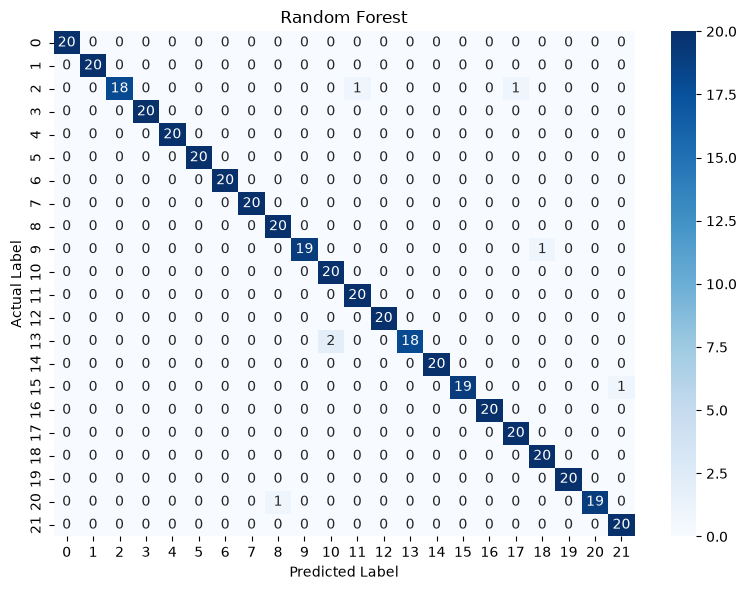

In [29]:
# ==========================================================
# Evaluate Model
# ==========================================================

num_classes = len(np.unique(y_test))
def precision_recall_f1(conf_matrix):
    """
    Calculate Precision, Recall and F1-Score
    for each class and return macro averages.
    """

    num_classes = conf_matrix.shape[0]

    precision_list = []
    recall_list = []
    f1_list = []

    for i in range(num_classes):

        tp = conf_matrix[i, i]

        fp = np.sum(conf_matrix[:, i]) - tp

        fn = np.sum(conf_matrix[i, :]) - tp

        # Precision
        if tp + fp == 0:
            precision = 0
        else:
            precision = tp / (tp + fp)

        # Recall
        if tp + fn == 0:
            recall = 0
        else:
            recall = tp / (tp + fn)

        # F1 Score
        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return (
        np.mean(precision_list),
        np.mean(recall_list),
        np.mean(f1_list)
    )

def confusion_matrix_scratch(y_true, y_pred, num_classes):
    """
    Generate confusion matrix.
    """
    matrix = np.zeros((num_classes, num_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        matrix[actual][predicted] += 1

    return matrix

rf_accuracy = accuracy(
    y_test,
    y_pred
)

# Confusion Matrix
rf_conf_matrix = confusion_matrix_scratch(
    y_test,
    y_pred,
    num_classes
)

# Metrics
rf_precision, rf_recall, rf_f1 = precision_recall_f1(
    rf_conf_matrix
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

plot_confusion_matrix(
    rf_conf_matrix,
    "Random Forest"
)


In [30]:
# ==========================================================
# Save Random Forest Model
# ==========================================================

with open("../saved_models/random_forest_model.pkl", "wb") as file:
    pickle.dump(random_forest, file)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


## Conclusion

In this notebook, we successfully implemented the Random Forest algorithm from scratch using the previously developed Decision Tree implementation.

The model was trained using bootstrap sampling, random feature selection, and majority voting to improve classification performance. Finally, the trained model was evaluated and saved for future use.
